In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("Test") \
    .config("spark.driver.extraJavaOptions", "--add-opens=java.base/java.lang=ALL-UNNAMED") \
    .config("spark.executor.extraJavaOptions", "--add-opens=java.base/java.lang=ALL-UNNAMED") \
    .getOrCreate()

print("Spark started")

Spark started


In [2]:
files = {
    "full_grouped": "full_grouped.csv",
    "covid_clean": "covid_19_clean_complete.csv",
    "country_latest": "country_wise_latest.csv",
    "day_wise": "day_wise.csv",
    "usa_county": "usa_county_wise.csv",
    "worldometer": "worldometer_data.csv"
}

In [3]:
dfs = {}
for name, path in files.items():
    df = spark.read.csv(
        path,
        header=True,
        inferSchema=True
    )
    dfs[name] = df

In [4]:
for name, df in dfs.items():
    print(f" {name.upper()} ")
    print("Schema: ")

    df.printSchema()

    print("Row Count: ")
    print(df.count())



 FULL_GROUPED 
Schema: 
root
 |-- Date: date (nullable = true)
 |-- Country/Region: string (nullable = true)
 |-- Confirmed: integer (nullable = true)
 |-- Deaths: integer (nullable = true)
 |-- Recovered: integer (nullable = true)
 |-- Active: integer (nullable = true)
 |-- New cases: integer (nullable = true)
 |-- New deaths: integer (nullable = true)
 |-- New recovered: integer (nullable = true)
 |-- WHO Region: string (nullable = true)

Row Count: 
35156
 COVID_CLEAN 
Schema: 
root
 |-- Province/State: string (nullable = true)
 |-- Country/Region: string (nullable = true)
 |-- Lat: double (nullable = true)
 |-- Long: double (nullable = true)
 |-- Date: date (nullable = true)
 |-- Confirmed: integer (nullable = true)
 |-- Deaths: integer (nullable = true)
 |-- Recovered: integer (nullable = true)
 |-- Active: integer (nullable = true)
 |-- WHO Region: string (nullable = true)

Row Count: 
49068
 COUNTRY_LATEST 
Schema: 
root
 |-- Country/Region: string (nullable = true)
 |-- Confirm

In [5]:
#2.1
df = dfs["covid_clean"]


In [6]:
from pyspark.sql.functions import col
null_rows = df.filter(col("Province/State").isNull())
null_rows.show()

+--------------+--------------------+---------+----------+----------+---------+------+---------+------+--------------------+
|Province/State|      Country/Region|      Lat|      Long|      Date|Confirmed|Deaths|Recovered|Active|          WHO Region|
+--------------+--------------------+---------+----------+----------+---------+------+---------+------+--------------------+
|          NULL|         Afghanistan| 33.93911| 67.709953|2020-01-22|        0|     0|        0|     0|Eastern Mediterra...|
|          NULL|             Albania|  41.1533|   20.1683|2020-01-22|        0|     0|        0|     0|              Europe|
|          NULL|             Algeria|  28.0339|    1.6596|2020-01-22|        0|     0|        0|     0|              Africa|
|          NULL|             Andorra|  42.5063|    1.5218|2020-01-22|        0|     0|        0|     0|              Europe|
|          NULL|              Angola| -11.2027|   17.8739|2020-01-22|        0|     0|        0|     0|              Africa|


In [7]:
#2.2
from pyspark.sql.functions import col, count
df = dfs["covid_clean"]
null_rows = df.filter(col("Province/State").isNull())
#null_rows.show()

null_count_report = null_rows.groupBy("Country/Region") \
    .agg(count("*").alias("null_count")) \
    .orderBy("null_count", ascending=False)

#null_count_report.show()
df_cleaned = df.fillna({
    "Province/State": "Unknown"
})

remaining_nulls = df_cleaned.filter(
    col("Province/State").isNull()
).count()


print(remaining_nulls)

    



0


In [8]:
#2.3
from pyspark.sql.functions import col, when, regexp_replace
full_grouped = dfs['full_grouped']
country_wise_latest = dfs['country_latest']
worldometer_data = dfs['worldometer']

def standardize_country_names(df, column_name):
    df = df.withColumn(
        column_name,
        when(col(column_name) == "US", "USA")
        .when(col(column_name) == "Korea, South", "South Korea")
        .when(col(column_name) == "UK", "United Kingdom")
        .otherwise(col(column_name)) 

    )

    df = df.withColumn(
        column_name,
        regexp_replace(col(column_name), "Mainland China", "China")

    )

    return df

print(type(full_grouped))
full_grouped_cleaned = standardize_country_names(
    full_grouped,
    "Country/Region"
)

country_wise_latest_cleaned = standardize_country_names(
    country_wise_latest,
    "Country/Region"
)

worldometer_data_cleaned = standardize_country_names(
    worldometer_data,
    "Country/Region"
)

print("Full Grouped Countries: ")
full_grouped_cleaned.select("Country/Region").distinct().show()
print("Country Wise Latest Countries:")
country_wise_latest_cleaned.select("Country/Region").distinct().show()

print("Worldometer Countries:")
worldometer_data_cleaned.select("Country/Region").distinct().show()



<class 'pyspark.sql.classic.dataframe.DataFrame'>
Full Grouped Countries: 
+--------------+
|Country/Region|
+--------------+
|          Chad|
|      Paraguay|
|        Russia|
|         Yemen|
|       Senegal|
|    Cabo Verde|
|        Sweden|
|        Guyana|
|         Burma|
|       Eritrea|
|   Philippines|
|      Djibouti|
|      Malaysia|
|     Singapore|
|          Fiji|
|        Turkey|
|        Malawi|
|Western Sahara|
|          Iraq|
|       Germany|
+--------------+
only showing top 20 rows
Country Wise Latest Countries:
+--------------+
|Country/Region|
+--------------+
|          Chad|
|      Paraguay|
|        Russia|
|         Yemen|
|       Senegal|
|    Cabo Verde|
|        Sweden|
|        Guyana|
|         Burma|
|       Eritrea|
|   Philippines|
|      Djibouti|
|      Malaysia|
|     Singapore|
|          Fiji|
|        Turkey|
|        Malawi|
|Western Sahara|
|          Iraq|
|       Germany|
+--------------+
only showing top 20 rows
Worldometer Countries:
+----

In [9]:
df = dfs["covid_clean"]
before_count = df.count()

duplicate_records = df.groupBy(
    "Country/Region",
    "Date"
).count().filter(col("count") > 1)

print("Duplicate Records : ")
duplicate_records.show()
df_no_duplicates = df.dropDuplicates([
    "Country/Region",
    "Date"
])

after_count = df_no_duplicates.count()


print("Rows Before Removing Duplicates:", before_count)
print("Rows After Removing Duplicates:", after_count)
print("Duplicates Removed:", before_count - after_count)



Duplicate Records : 
+--------------+----------+-----+
|Country/Region|      Date|count|
+--------------+----------+-----+
|         China|2020-05-01|   33|
|   Netherlands|2020-06-08|    4|
|     Australia|2020-06-10|    8|
|       Denmark|2020-06-21|    2|
|United Kingdom|2020-07-03|   11|
|   Netherlands|2020-04-20|    4|
|     Australia|2020-05-10|    8|
|     Australia|2020-07-16|    8|
|United Kingdom|2020-05-03|   11|
|     Australia|2020-05-14|    8|
|     Australia|2020-05-29|    8|
|         China|2020-06-06|   33|
|   Netherlands|2020-07-12|    4|
|        France|2020-07-13|   11|
|        Canada|2020-07-25|   12|
|       Denmark|2020-07-25|    2|
|         China|2020-01-28|   33|
|       Denmark|2020-02-25|    2|
|     Australia|2020-05-01|    8|
|        France|2020-05-27|   11|
+--------------+----------+-----+
only showing top 20 rows
Rows Before Removing Duplicates: 49068
Rows After Removing Duplicates: 35156
Duplicates Removed: 13912


+--------------+---------+
|Country/Region|Confirmed|
+--------------+---------+
|           USA|  4290259|
|        Brazil|  2442375|
|         India|  1480073|
|        Russia|   816680|
|  South Africa|   452529|
|        Mexico|   395489|
|          Peru|   389717|
|         Chile|   347923|
|United Kingdom|   301708|
|          Iran|   293606|
+--------------+---------+



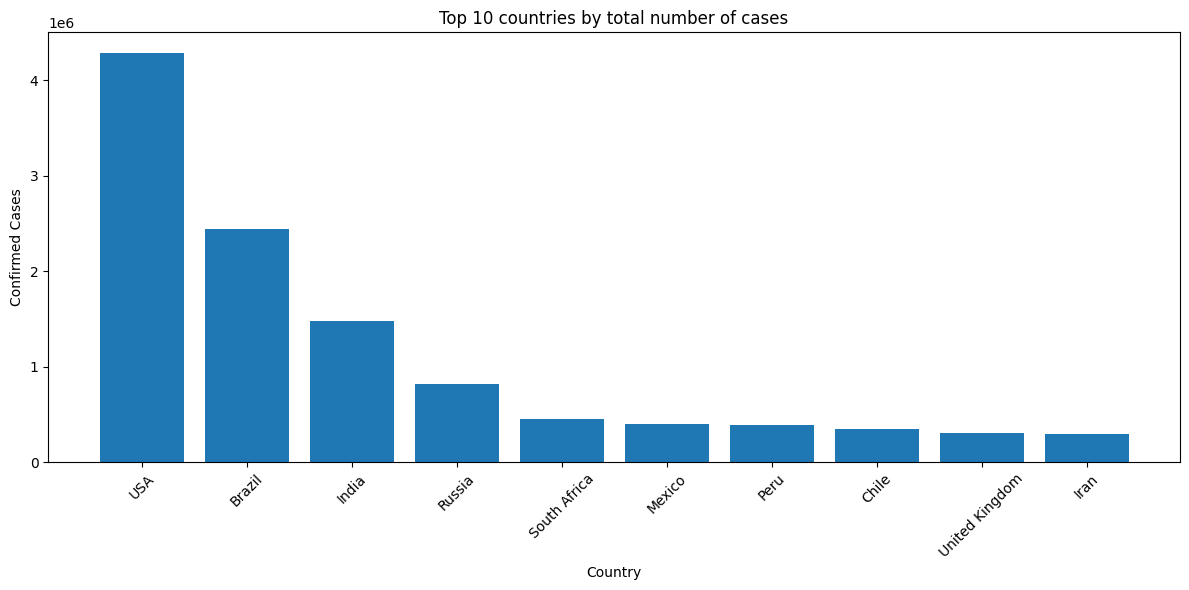

In [10]:
import matplotlib.pyplot as plt

country_wise = country_wise_latest_cleaned

top_10 = country_wise.select(
    "Country/Region",
    "Confirmed"
).orderBy(
    col("Confirmed").desc()
).limit(10)

top_10.show()

top_10_pd = top_10.toPandas()
plt.figure(figsize=(12,6))

plt.bar(
    top_10_pd["Country/Region"],
    top_10_pd["Confirmed"]
)

plt.xticks(rotation = 45)
plt.xlabel("Country")
plt.ylabel("Confirmed Cases")
plt.title("Top 10 countries by total number of cases")

plt.tight_layout()
plt.show()

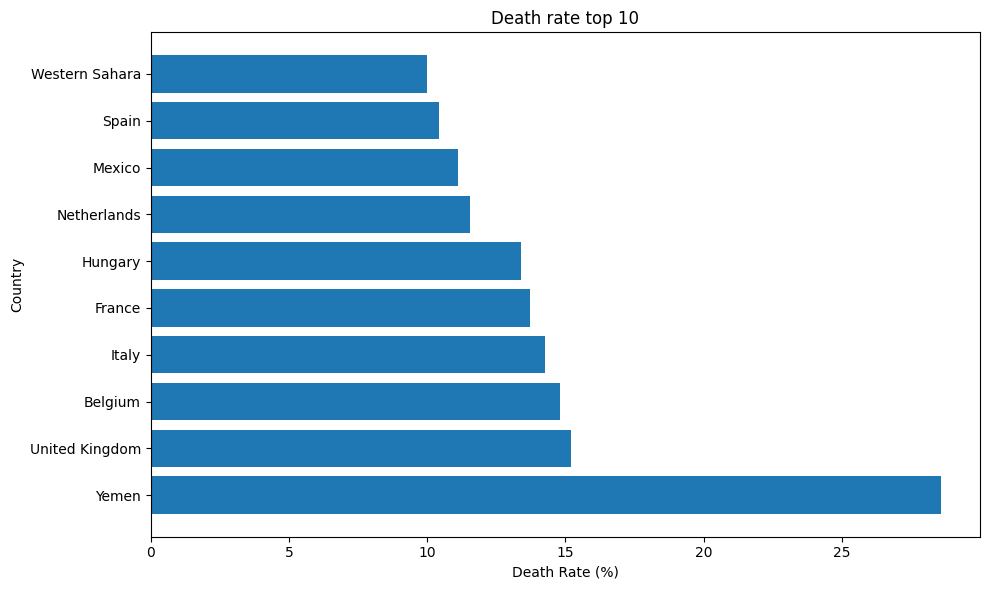

In [11]:
#3.6
country_wise = country_wise.withColumn("death_rate", (col("Deaths")) / (col("Confirmed")) * 100)
top_10_death_rate = country_wise.select(
    "Country/Region",
    "death_rate"

).orderBy(
    col("death_rate").desc()
).limit(10)

#top_10_death_rate.show()
top_10_pd = top_10_death_rate.toPandas()
plt.figure(figsize = (10, 6))
plt.barh(top_10_pd["Country/Region"], top_10_pd["death_rate"])

plt.xlabel("Death Rate (%)")
plt.ylabel("Country")
plt.title("Death rate top 10")

plt.gca().invert_yaxis
plt.tight_layout()
plt.show()



+--------------------+---------------+------------+---------------+
|          WHO Region|Total_Confirmed|Total_Deaths|Total_Recovered|
+--------------------+---------------+------------+---------------+
|              Europe|      248879793|    19271040|      123202075|
|     Western Pacific|       26374411|      932430|       18861950|
|              Africa|       21791827|      439978|       11193730|
|Eastern Mediterra...|       74082892|     1924029|       48050703|
|            Americas|      402261194|    19359292|      157069444|
|     South-East Asia|       55118365|     1458134|       30030327|
+--------------------+---------------+------------+---------------+



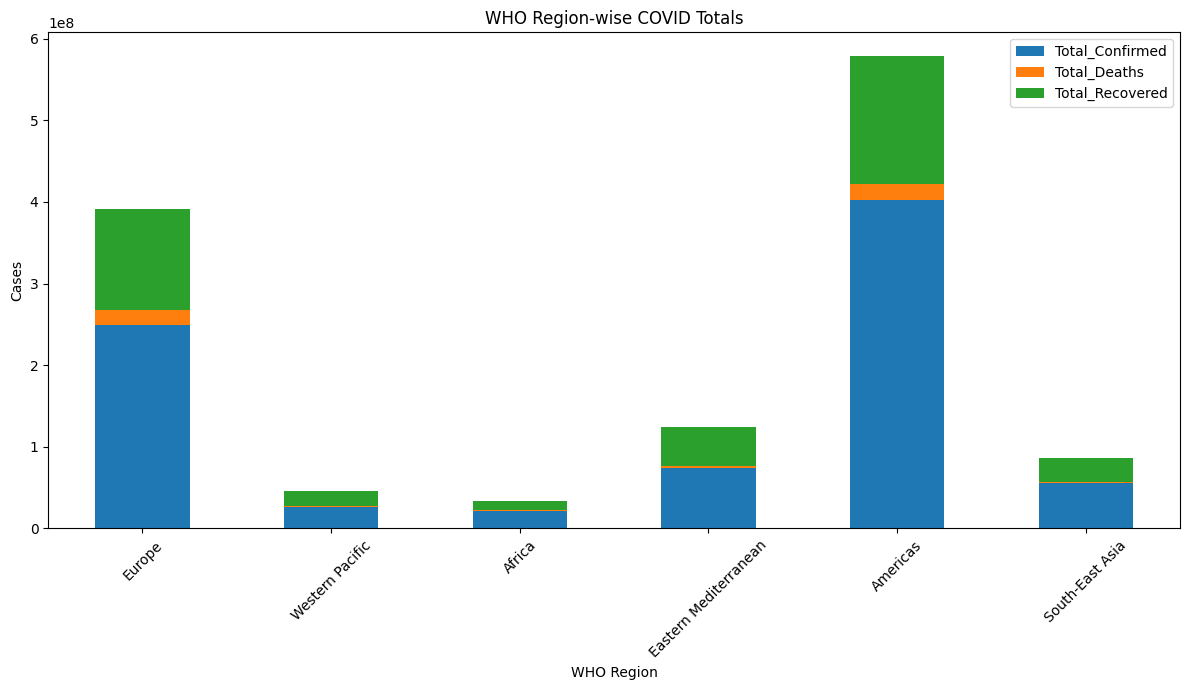

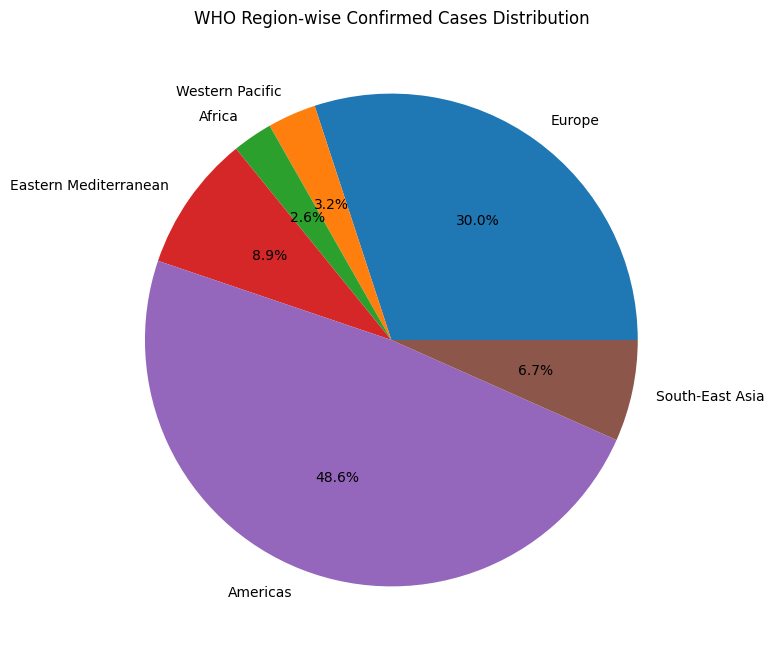

In [12]:
from pyspark.sql.functions import sum as spark_sum
import matplotlib.pyplot as plt
import pandas as pd

who_region_totals = full_grouped_cleaned.groupBy("WHO Region").agg(
    spark_sum("Confirmed").alias("Total_Confirmed"),
    spark_sum("Deaths").alias("Total_Deaths"),
    spark_sum("Recovered").alias("Total_Recovered")


)

who_region_totals.show() 

who_pd = who_region_totals.toPandas()

who_pd.set_index("WHO Region")[[
    "Total_Confirmed",
    "Total_Deaths",
    "Total_Recovered"
]].plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7)
)

plt.xlabel("WHO Region")
plt.ylabel("Cases")
plt.title("WHO Region-wise COVID Totals")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 8))

plt.pie(
    who_pd["Total_Confirmed"],
    labels=who_pd["WHO Region"],
    autopct="%1.1f%%"
)

plt.title("WHO Region-wise Confirmed Cases Distribution")

plt.show()

+----------+---------+
|      Date|New Cases|
+----------+---------+
|2020-01-22|        0|
|2020-01-23|       99|
|2020-01-24|      287|
|2020-01-25|      493|
|2020-01-26|      684|
|2020-01-27|      809|
|2020-01-28|     2651|
|2020-01-29|      588|
|2020-01-30|     2068|
|2020-01-31|     1693|
|2020-02-01|     2111|
|2020-02-02|     4749|
|2020-02-03|     3100|
|2020-02-04|     4011|
|2020-02-05|     3745|
|2020-02-06|     3159|
|2020-02-07|     3532|
|2020-02-08|     2734|
|2020-02-09|     3027|
|2020-02-10|     2538|
+----------+---------+
only showing top 20 rows


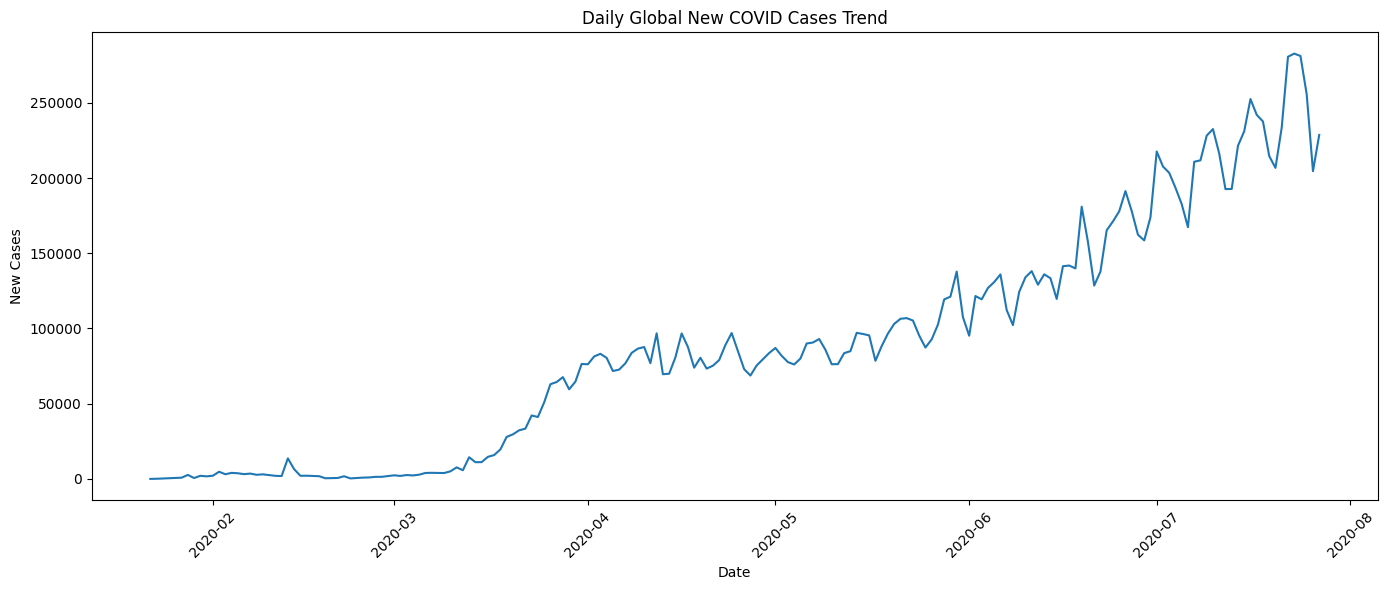

In [13]:
#4.8
day_wise = dfs["day_wise"]

daily_cases = day_wise.select("Date", "New Cases").orderBy("Date")
daily_cases.show()

daily_cases_pd = daily_cases.toPandas()


plt.figure(figsize=(14, 6))

plt.plot(
    daily_cases_pd["Date"],
    daily_cases_pd["New Cases"]
)


plt.xlabel("Date")
plt.ylabel("New Cases")
plt.title("Daily Global New COVID Cases Trend")


plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

+----------+----------+-------------------+-----------------------+
|      Date|New Deaths|previous_day_deaths|death_growth_percentage|
+----------+----------+-------------------+-----------------------+
|2020-01-22|         0|               NULL|                    0.0|
|2020-01-23|         1|                 17|       5.88235294117647|
|2020-01-24|         8|                 18|      44.44444444444444|
|2020-01-25|        16|                 26|      61.53846153846154|
|2020-01-26|        14|                 42|      33.33333333333333|
|2020-01-27|        26|                 56|      46.42857142857143|
|2020-01-28|        49|                 82|     59.756097560975604|
|2020-01-29|         2|                131|     1.5267175572519083|
|2020-01-30|        38|                133|      28.57142857142857|
|2020-01-31|        42|                171|     24.561403508771928|
|2020-02-01|        46|                213|       21.5962441314554|
|2020-02-02|       103|                259|     

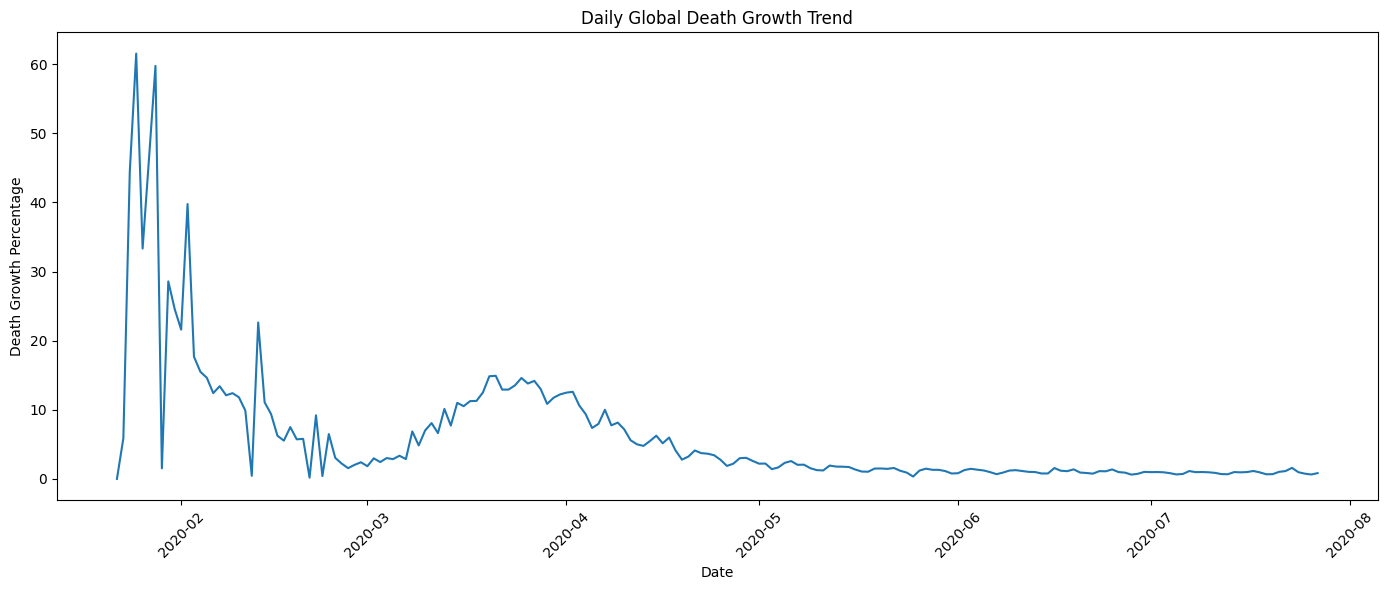

In [14]:
from pyspark.sql.window import Window
from pyspark.sql.functions import col, lag, when
import matplotlib.pyplot as plt
#4.9
window_spec = Window.orderBy("Date")
day_wise_growth = day_wise.withColumn("previous_day_deaths", lag("Deaths").over(window_spec))

day_wise_growth = day_wise_growth.withColumn(
    "death_growth_percentage",
    when(
        col("previous_day_deaths") != 0,
        (col("New Deaths") / col("previous_day_deaths")) * 100

    ).otherwise(0)
)

growth_trend = day_wise_growth.select(
    "Date",
    "New Deaths",
    "previous_day_deaths",
    "death_growth_percentage"
)

growth_trend.show()


growth_pd = growth_trend.toPandas()


plt.figure(figsize=(14, 6))

plt.plot(
    growth_pd["Date"],
    growth_pd["death_growth_percentage"]
)


plt.xlabel("Date")
plt.ylabel("Death Growth Percentage")
plt.title("Daily Global Death Growth Trend")


plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

+-----+---------------------+
|Month|Total Confirmed Cases|
+-----+---------------------+
|    1|                38534|
|    2|              1663437|
|    3|              9002815|
|    4|             63391662|
|    5|            144990399|
|    6|            246525787|
|    7|            362895848|
+-----+---------------------+



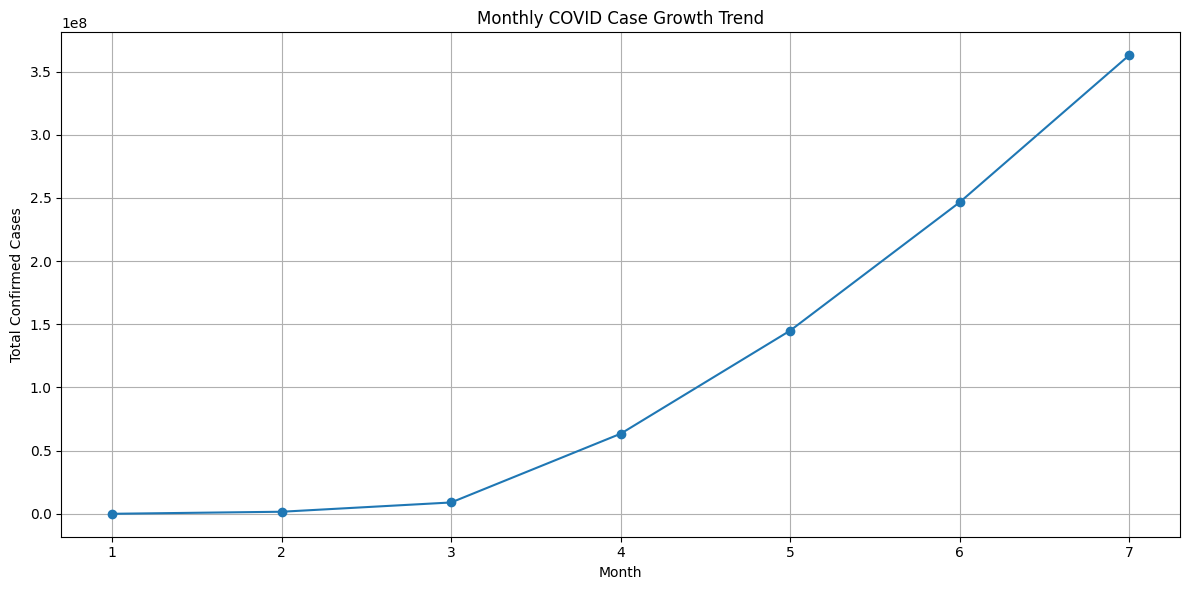

In [15]:
#3.10
from pyspark.sql.functions import month, col, sum as spark_sum
import matplotlib.pyplot as pl
monthly_cases = full_grouped_cleaned.withColumn(
    "Month",
    month(col("Date"))
).groupBy(
    "Month"
).agg(
    spark_sum("Confirmed").alias("Total Confirmed Cases")
).orderBy("Month")

monthly_cases.show()

monthly_cases_pd = monthly_cases.toPandas()


plt.figure(figsize=(12, 6))

plt.plot(
    monthly_cases_pd["Month"],
    monthly_cases_pd["Total Confirmed Cases"],
    marker='o'
)


plt.xlabel("Month")
plt.ylabel("Total Confirmed Cases")
plt.title("Monthly COVID Case Growth Trend")


plt.xticks(monthly_cases_pd["Month"])


plt.grid(True)

plt.tight_layout()
plt.show()

+--------------------+--------------+---------+----+
|          WHO Region|Country/Region|Confirmed|rank|
+--------------------+--------------+---------+----+
|              Africa|  South Africa|   452529|   1|
|              Africa|       Nigeria|    41180|   2|
|              Africa|         Ghana|    33624|   3|
|              Africa|       Algeria|    27973|   4|
|              Africa|         Kenya|    17975|   5|
|            Americas|           USA|  4290259|   1|
|            Americas|        Brazil|  2442375|   2|
|            Americas|        Mexico|   395489|   3|
|            Americas|          Peru|   389717|   4|
|            Americas|         Chile|   347923|   5|
|Eastern Mediterra...|          Iran|   293606|   1|
|Eastern Mediterra...|      Pakistan|   274289|   2|
|Eastern Mediterra...|  Saudi Arabia|   268934|   3|
|Eastern Mediterra...|          Iraq|   112585|   4|
|Eastern Mediterra...|         Qatar|   109597|   5|
|              Europe|        Russia|   816680

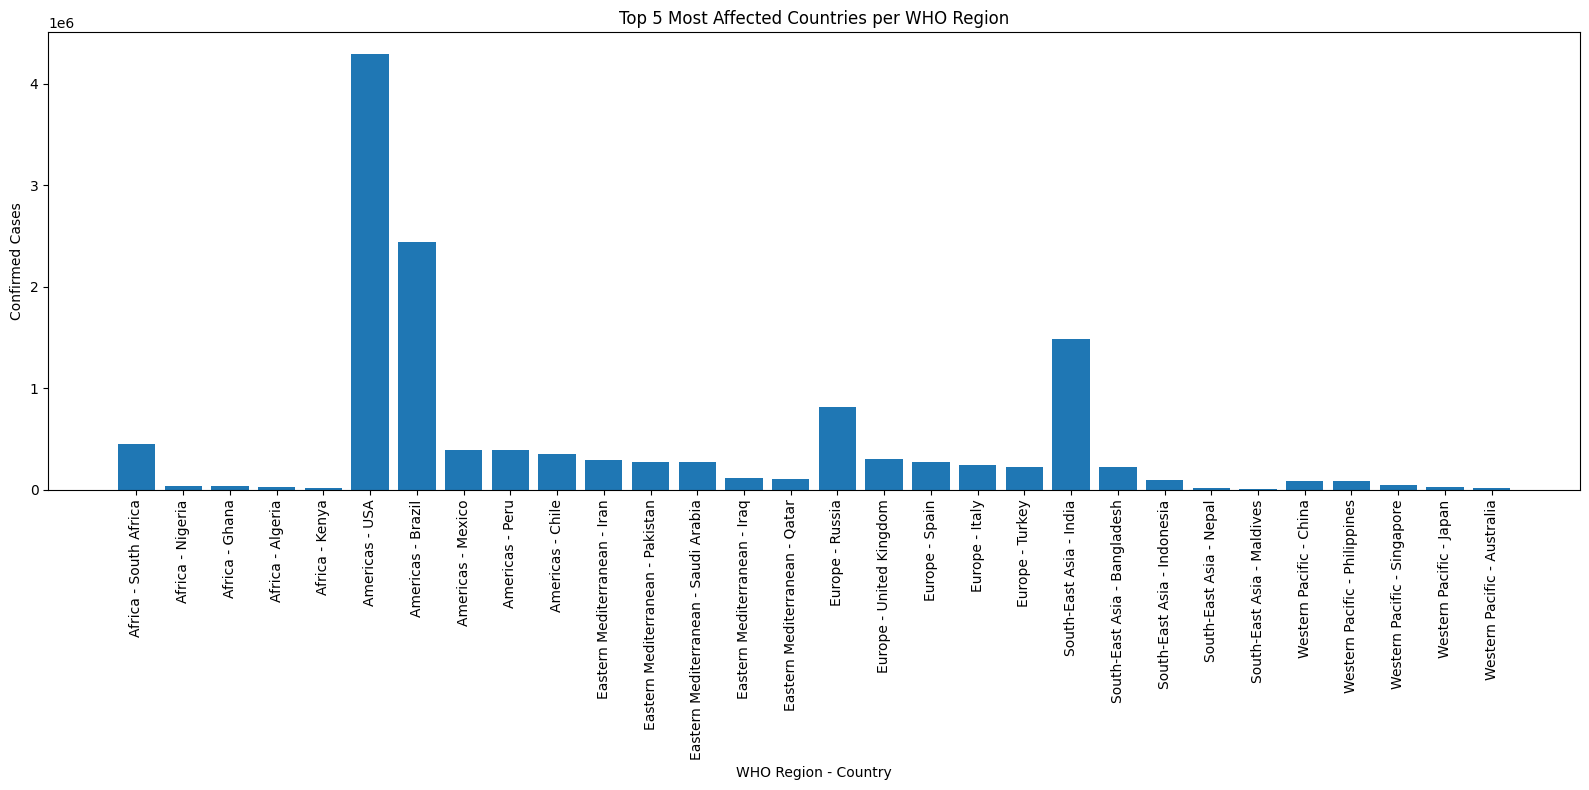

In [16]:
from pyspark.sql.window import Window
from pyspark.sql.functions import col, dense_rank
import matplotlib.pyplot as plt
import pandas as pd

window_spec = Window.partitionBy("WHO Region").orderBy(col("confirmed").desc())
ranked = country_wise.withColumn(
    "rank",
    dense_rank().over(window_spec)
)
top_5_per_region = ranked.filter(
    col("rank") <= 5
).select(
    "WHO Region",
    "Country/Region",
    "Confirmed",
    "rank"
).orderBy(
    "WHO Region",
    "rank"
)

top_5_per_region.show()


top_5_pd = top_5_per_region.toPandas()


plt.figure(figsize=(16, 8))


labels = top_5_pd["WHO Region"] + " - " + top_5_pd["Country/Region"]

plt.bar(
    labels,
    top_5_pd["Confirmed"]
)


plt.xlabel("WHO Region - Country")
plt.ylabel("Confirmed Cases")
plt.title("Top 5 Most Affected Countries per WHO Region")

# Rotate labels
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

+--------------+----------+---------+-------------------+-------------------+
|Country/Region|      Date|Confirmed|yesterday_confirmed|daily_case_increase|
+--------------+----------+---------+-------------------+-------------------+
|   Afghanistan|2020-01-22|        0|               NULL|               NULL|
|   Afghanistan|2020-01-23|        0|                  0|                  0|
|   Afghanistan|2020-01-24|        0|                  0|                  0|
|   Afghanistan|2020-01-25|        0|                  0|                  0|
|   Afghanistan|2020-01-26|        0|                  0|                  0|
|   Afghanistan|2020-01-27|        0|                  0|                  0|
|   Afghanistan|2020-01-28|        0|                  0|                  0|
|   Afghanistan|2020-01-29|        0|                  0|                  0|
|   Afghanistan|2020-01-30|        0|                  0|                  0|
|   Afghanistan|2020-01-31|        0|                  0|       

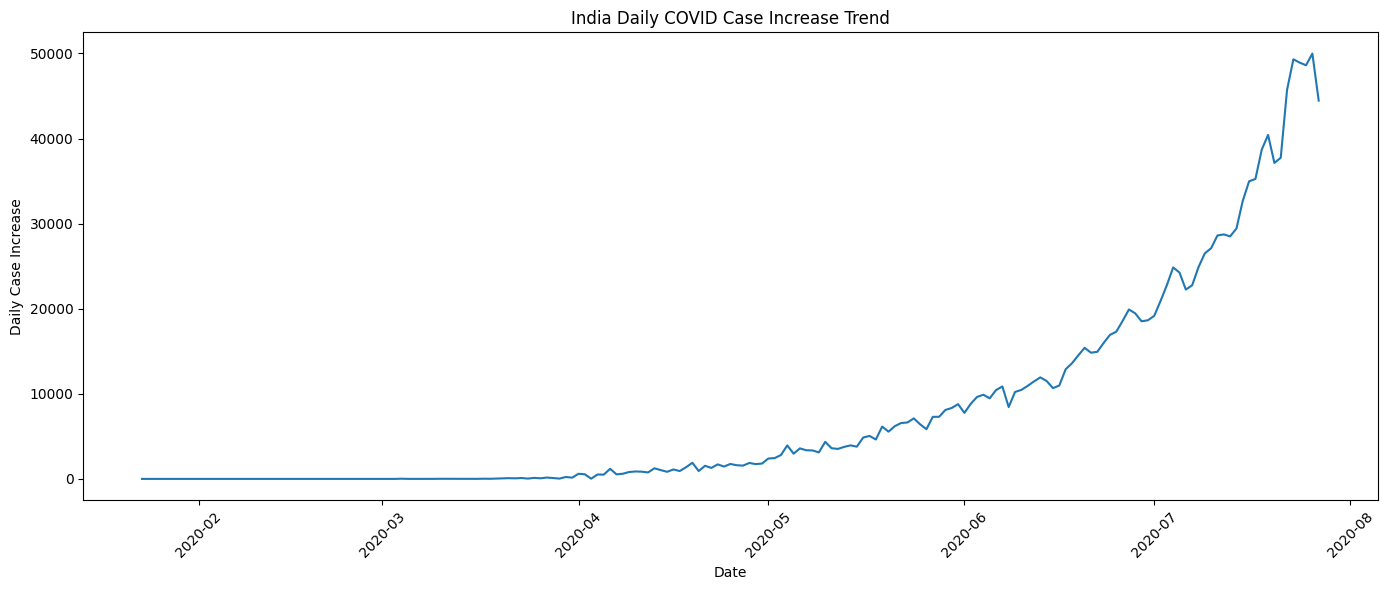

In [17]:
window_spec = Window.partitionBy(
    "Country/Region"
).orderBy("Date")

daily_increase_df = full_grouped_cleaned.withColumn(
    "yesterday_confirmed",
    lag("Confirmed").over(window_spec)
)

daily_increase_df = daily_increase_df.withColumn(
    "daily_case_increase",
    col("Confirmed") - col("yesterday_confirmed")

)
result_df = daily_increase_df.select(
    "Country/Region",
    "Date",
    "Confirmed",
    "yesterday_confirmed",
    "daily_case_increase"
)


result_df.show()



india_trend = result_df.filter(
    col("Country/Region") == "India"
).orderBy("Date")


india_pd = india_trend.toPandas()


plt.figure(figsize=(14, 6))

plt.plot(
    india_pd["Date"],
    india_pd["daily_case_increase"]
)


plt.xlabel("Date")
plt.ylabel("Daily Case Increase")
plt.title("India Daily COVID Case Increase Trend")


plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [18]:
#6.13

# Load datasets
from pyspark.sql.functions import abs
# Select and rename columns for clarity
country_df = country_wise_latest.select(
    col("Country/Region").alias("Country"),
    col("Confirmed").alias("Confirmed_latest"),
    col("Deaths").alias("Deaths_latest"),
    col("Recovered").alias("Recovered_latest")
)

worldometer_df = worldometer_data.select(
    col("Country/Region").alias("Country"),
    col("TotalCases").alias("Confirmed_worldometer"),
    col("TotalDeaths").alias("Deaths_worldometer"),
    col("TotalRecovered").alias("Recovered_worldometer")
)

# Join datasets on country
joined_df = country_df.join(
    worldometer_df,
    on="Country",
    how="inner"
)

# Calculate differences
comparison_df = joined_df.withColumn(
    "Confirmed_Difference",
    abs(col("Confirmed_latest") - col("Confirmed_worldometer"))
).withColumn(
    "Death_Difference",
    abs(col("Deaths_latest") - col("Deaths_worldometer"))
).withColumn(
    "Recovery_Difference",
    abs(col("Recovered_latest") - col("Recovered_worldometer"))
)

# Find countries with large mismatches
large_mismatches = comparison_df.filter(
    (col("Confirmed_Difference") > 10000) |
    (col("Death_Difference") > 1000) |
    (col("Recovery_Difference") > 10000)
)

# Show results
large_mismatches.select(
    "Country",
    "Confirmed_Difference",
    "Death_Difference",
    "Recovery_Difference"
).show(truncate=False)

+------------+--------------------+----------------+-------------------+
|Country     |Confirmed_Difference|Death_Difference|Recovery_Difference|
+------------+--------------------+----------------+-------------------+
|Brazil      |475187              |11026           |201019             |
|India       |545336              |8230            |426218             |
|Russia      |55214               |1272            |74108              |
|South Africa|85655               |2537            |112391             |
|Mexico      |67201               |6495            |5038               |
|Peru        |65692               |2006            |37790              |
|Chile       |18748               |702             |20214              |
|Colombia    |100609              |3162            |61194              |
|Spain       |82109               |68              |NULL               |
|Iran        |26511               |2064            |22319              |
|Saudi Arabia|15292               |295             

+--------------+------------------+
|Country/Region|    infection_rate|
+--------------+------------------+
|         Qatar|3.9921575750452756|
| French Guiana|2.7145648579588157|
|       Bahrain|2.5130239079751258|
|    San Marino|2.0596381637102956|
|         Chile|1.9164810228284688|
|        Panama| 1.652703989232825|
|        Kuwait|1.6378443167538763|
|          Oman|1.5769043963734304|
|           USA|1.5193862960518527|
|  Vatican City|1.4981273408239701|
|          Peru|1.3793451656436928|
|        Brazil|1.3716104125127853|
|       Armenia| 1.343506721582449|
|       Andorra| 1.221563705064831|
|    Luxembourg|1.1281565414896195|
|       Mayotte| 1.112578131000406|
|     Singapore|0.9317785415782796|
|  South Africa|0.9063149328193871|
|        Israel|0.8649983310845557|
|      Maldives|0.8643489310146126|
+--------------+------------------+
only showing top 20 rows


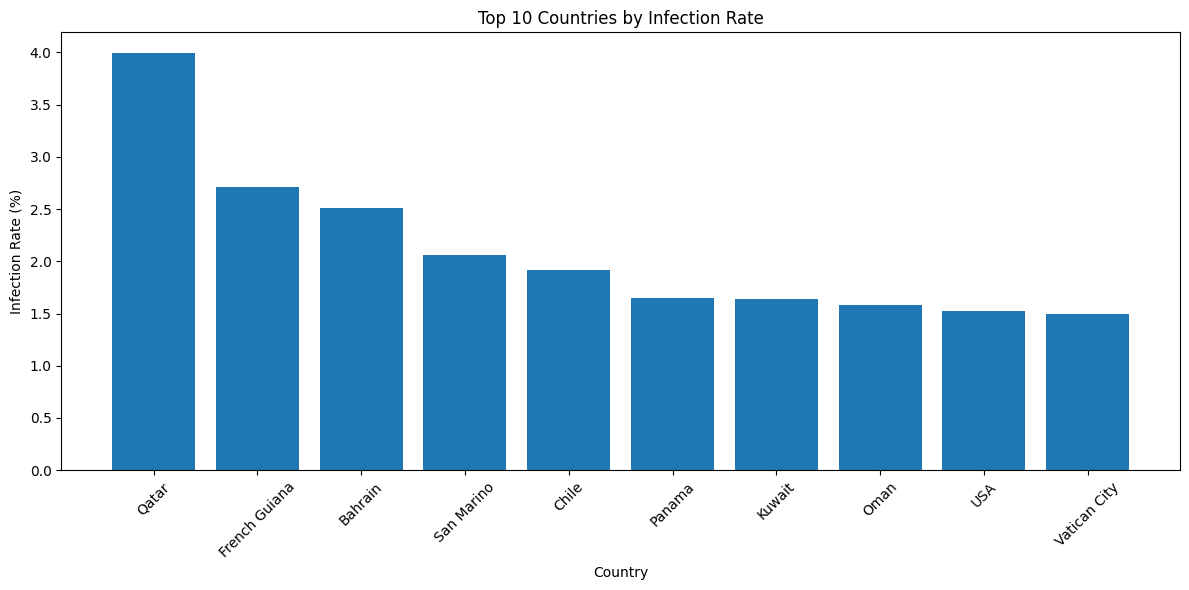

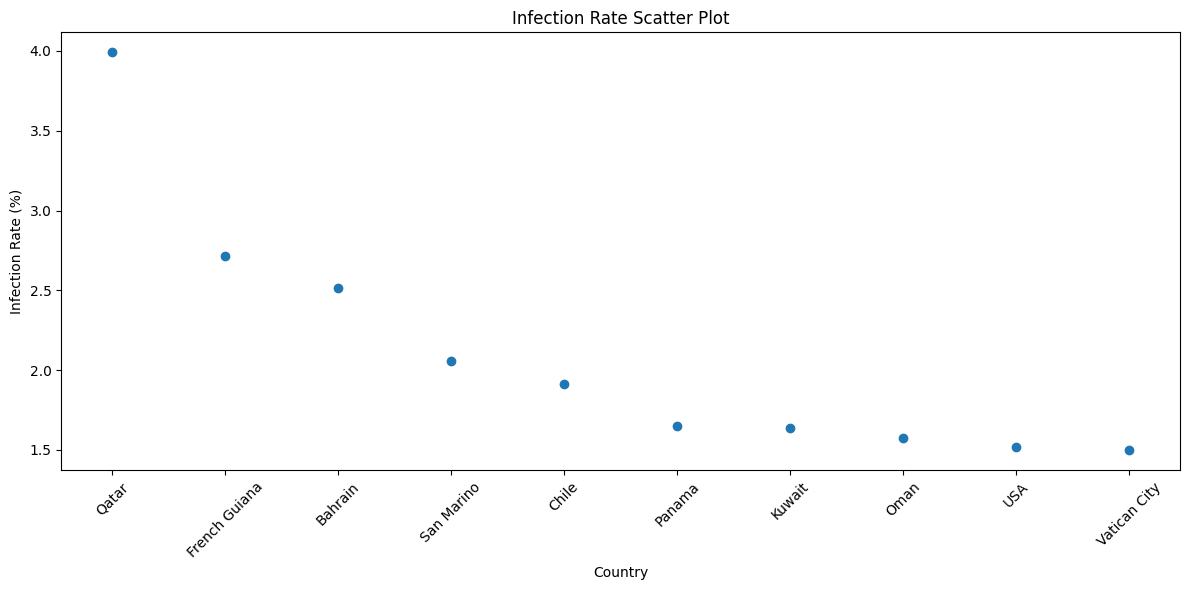

In [19]:
#14
worldometer_data_cleaned= worldometer_data_cleaned.withColumn(
    "infection_rate", ((col("TotalCases") / col("Population"))* 100)
)

infection_rate_df = worldometer_data_cleaned.select(
    "Country/Region",
    "infection_rate"
).orderBy(
    col("infection_rate").desc()
)

infection_rate_df.show()

top_10_infection = infection_rate_df.limit(10)


top_10_pd = top_10_infection.toPandas()


plt.figure(figsize=(12, 6))

plt.bar(
    top_10_pd["Country/Region"],
    top_10_pd["infection_rate"]
)

plt.xlabel("Country")
plt.ylabel("Infection Rate (%)")
plt.title("Top 10 Countries by Infection Rate")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 6))

plt.scatter(
    top_10_pd["Country/Region"],
    top_10_pd["infection_rate"]
)

plt.xlabel("Country")
plt.ylabel("Infection Rate (%)")
plt.title("Infection Rate Scatter Plot")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


+--------------+------------------+
|Province_State|Number_of_Counties|
+--------------+------------------+
|         Texas|             48128|
|       Georgia|             30268|
|      Virginia|             25380|
|      Kentucky|             22936|
|      Missouri|             22184|
|        Kansas|             20116|
|      Illinois|             19552|
|North Carolina|             19176|
|          Iowa|             18988|
|     Tennessee|             18236|
|      Nebraska|             17860|
|       Indiana|             17672|
|          Ohio|             16920|
|     Minnesota|             16732|
|      Michigan|             16356|
|   Mississippi|             15792|
|   Puerto Rico|             15040|
|      Oklahoma|             14852|
|      Arkansas|             14476|
|     Wisconsin|             13912|
+--------------+------------------+
only showing top 20 rows


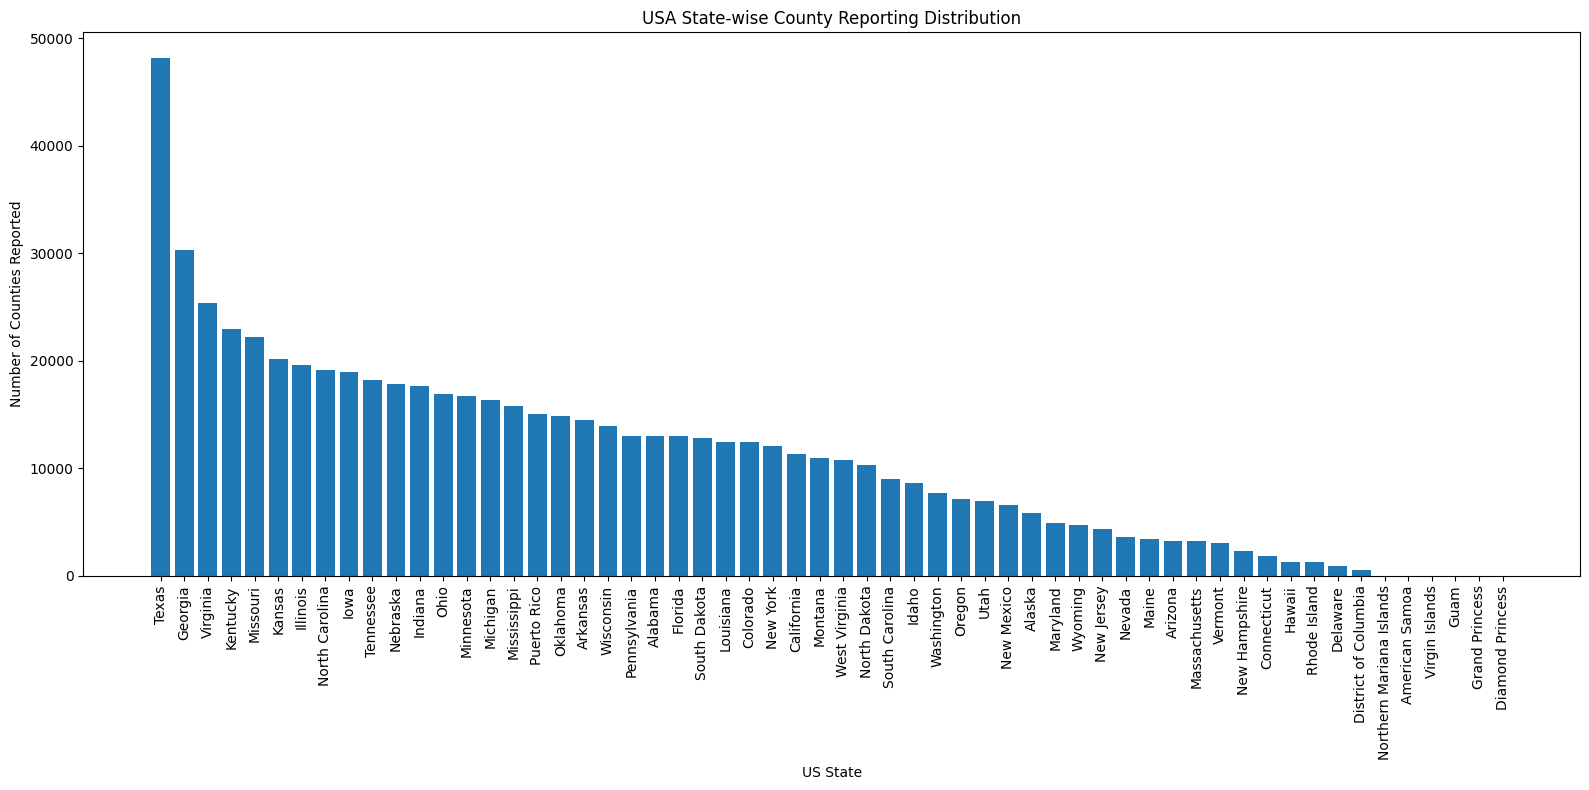

In [20]:
#15
usa_county_wise = dfs["usa_county"]
state_counties = usa_county_wise.groupBy(
    "Province_State"
).agg(
    count("Admin2").alias("Number_of_Counties")
).orderBy(
    "Number_of_Counties",
    ascending=False
)

state_counties.show()

state_counties_pd = state_counties.toPandas()


plt.figure(figsize=(16, 8))

plt.bar(
    state_counties_pd["Province_State"],
    state_counties_pd["Number_of_Counties"]
)


plt.xlabel("US State")
plt.ylabel("Number of Counties Reported")
plt.title("USA State-wise County Reporting Distribution")


plt.xticks(rotation=90)

plt.tight_layout()
plt.show()


+------------------+---------+---------+
|          Latitude|Longitude|Confirmed|
+------------------+---------+---------+
|           31.8257| 117.2264|        1|
|           40.1824| 116.4142|       14|
|           30.0572|  107.874|        6|
|           26.0789| 117.9874|        1|
|           23.3417| 113.4244|       26|
|           23.8298| 108.7881|        2|
|           26.8154| 106.8748|        1|
|           19.1959| 109.7453|        4|
|            39.549| 116.1306|        1|
|           37.8957| 114.9042|        5|
|           30.9756| 112.2707|      444|
|           27.6104| 111.7088|        4|
|           32.9711|  119.455|        1|
|            27.614| 115.7221|        2|
|           41.2956| 122.6085|        2|
|           22.1667|   113.55|        1|
|           37.2692| 106.1655|        1|
|           36.3427| 118.1498|        2|
|31.201999999999998| 121.4491|        9|
|           37.5777| 112.2922|        1|
+------------------+---------+---------+
only showing top

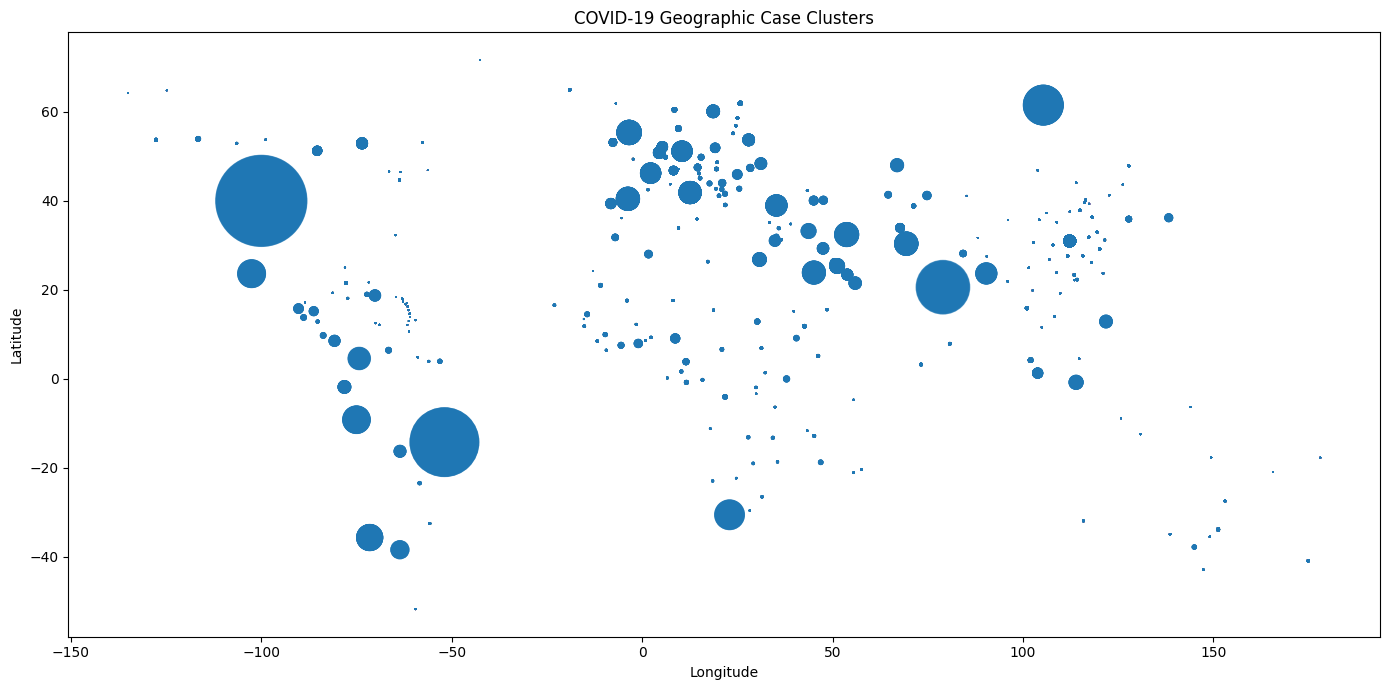

In [21]:
#16
covid_clean = dfs["covid_clean"]

geo_cases = covid_clean.select(
    col("Lat").alias("Latitude"),
    col("Long").alias("Longitude"),
    col("Confirmed")
).filter(
    col("Confirmed") > 0
)


geo_cases.show()


geo_cases_pd = geo_cases.toPandas()


plt.figure(figsize=(14, 7))

plt.scatter(
    geo_cases_pd["Longitude"],
    geo_cases_pd["Latitude"],
    s=geo_cases_pd["Confirmed"] / 1000,
    alpha=0.6
)


plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("COVID-19 Geographic Case Clusters")

plt.tight_layout()
plt.show()

+--------------+-----------------+
|Country/Region|    Recovery_Rate|
+--------------+-----------------+
|      Holy See|            100.0|
|       Grenada|            100.0|
|      Dominica|            100.0|
|      Djibouti|98.37912630954733|
|       Iceland| 98.3279395900755|
|        Brunei|97.87234042553192|
|   New Zealand|97.23827874116891|
|         Qatar| 97.0172541219194|
|      Malaysia|96.59703504043127|
|     Mauritius|96.51162790697676|
+--------------+-----------------+

+--------------+-------------------+
|Country/Region|      Recovery_Rate|
+--------------+-------------------+
|        Canada|                0.0|
|    Mozambique|                0.0|
|        Serbia|                0.0|
|        Sweden|                0.0|
|         Syria|                0.0|
|   Timor-Leste|                0.0|
|   Netherlands|0.35384644187744557|
|United Kingdom|0.47628833176448754|
|       Namibia|  5.480195333695062|
|      Botswana|  8.525033829499323|
+--------------+------------

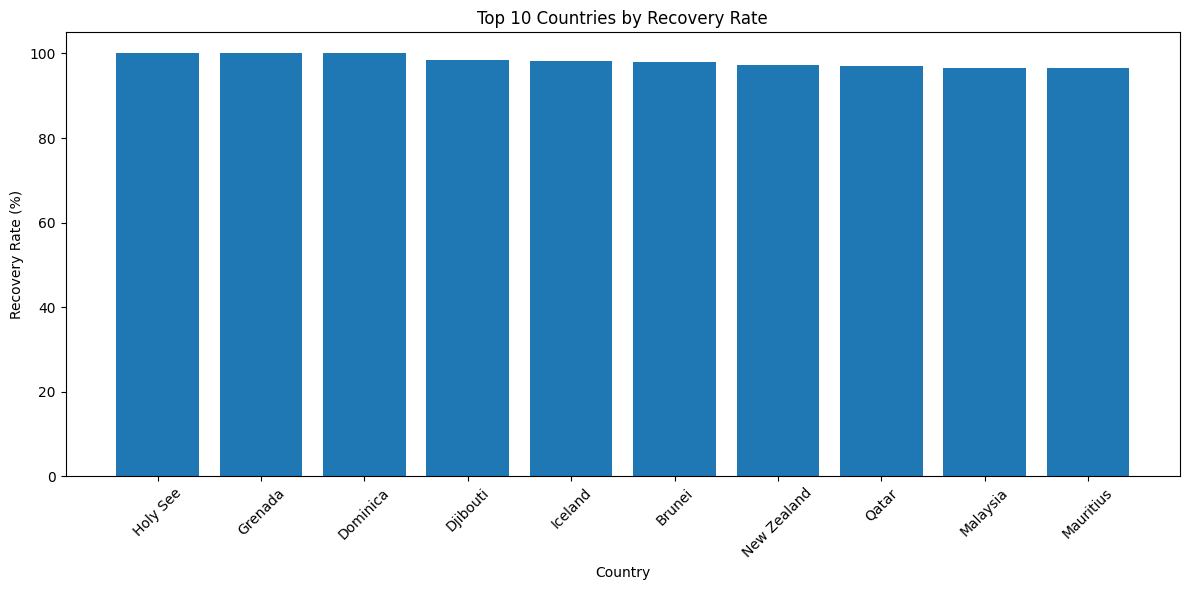

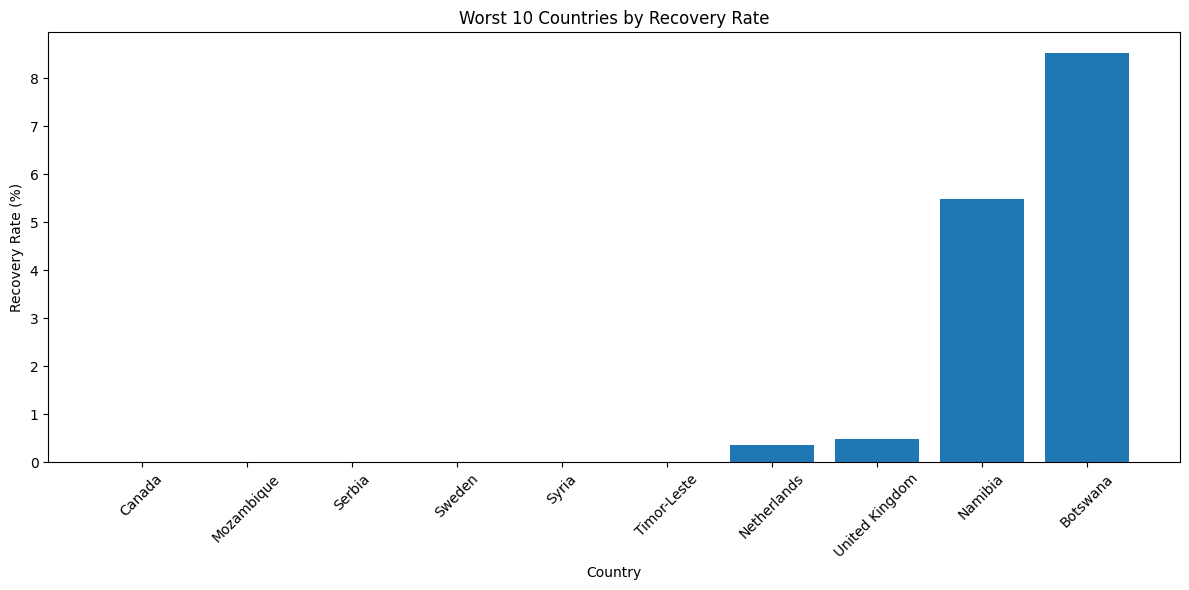

In [22]:
from pyspark.sql.functions import col, when
import matplotlib.pyplot as plt



country_wise = country_wise.withColumn(
    "Recovery_Rate",
    when(
        col("Confirmed") != 0,
        (col("Recovered") / col("Confirmed")) * 100
    ).otherwise(0)
)

best_recovery = country_wise.select(
    "Country/Region",
    "Recovery_Rate"
).orderBy(
    col("Recovery_Rate").desc()
).limit(10)

worst_recovery = country_wise.select(
    "Country/Region",
    "Recovery_Rate"
).orderBy(
    col("Recovery_Rate").asc()
).limit(10)

best_recovery.show()

worst_recovery.show()

best_pd = best_recovery.toPandas()
worst_pd = worst_recovery.toPandas()

plt.figure(figsize=(12, 6))

plt.bar(
    best_pd["Country/Region"],
    best_pd["Recovery_Rate"]
)

plt.xlabel("Country")
plt.ylabel("Recovery Rate (%)")
plt.title("Top 10 Countries by Recovery Rate")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))

plt.bar(
    worst_pd["Country/Region"],
    worst_pd["Recovery_Rate"]
)

plt.xlabel("Country")
plt.ylabel("Recovery Rate (%)")
plt.title("Worst 10 Countries by Recovery Rate")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [23]:
#18
high_risk_countries = country_wise.filter(
    col("Active") > col("Recovered")
).select(
    "Country/Region",
    "Confirmed",
    "Active",
    "Recovered",
    "Deaths"
).orderBy(
    col("Active").desc()
)

high_risk_countries.show(truncate=False)

+------------------+---------+-------+---------+------+
|Country/Region    |Confirmed|Active |Recovered|Deaths|
+------------------+---------+-------+---------+------+
|USA               |4290259  |2816444|1325804  |148011|
|United Kingdom    |301708   |254427 |1437     |45844 |
|France            |220352   |108928 |81212    |30212 |
|Canada            |116458   |107514 |0        |8944  |
|Argentina         |167416   |91782  |72575    |3059  |
|Sweden            |79395    |73695  |0        |5700  |
|Philippines       |82040    |53649  |26446    |1945  |
|Egypt             |92482    |52992  |34838    |4652  |
|Netherlands       |53413    |47064  |189      |6160  |
|Bolivia           |71181    |47056  |21478    |2647  |
|Ecuador           |81161    |40733  |34896    |5532  |
|Belgium           |66428    |39154  |17452    |9822  |
|Israel            |63985    |36378  |27133    |474   |
|Honduras          |39741    |33536  |5039     |1166  |
|Dominican Republic|64156    |32869  |30204    |

Maximum New Cases:
Row(Date=datetime.date(2020, 7, 23), Confirmed=15510481, Deaths=633506, Recovered=8710969, Active=6166006, New cases=282756, New deaths=9966, New recovered=169714, Deaths / 100 Cases=4.08, Recovered / 100 Cases=56.16, Deaths / 100 Recovered=7.27, No. of countries=187)
Maximum New Deaths:
Row(Date=datetime.date(2020, 7, 23), Confirmed=15510481, Deaths=633506, Recovered=8710969, Active=6166006, New cases=282756, New deaths=9966, New recovered=169714, Deaths / 100 Cases=4.08, Recovered / 100 Cases=56.16, Deaths / 100 Recovered=7.27, No. of countries=187)


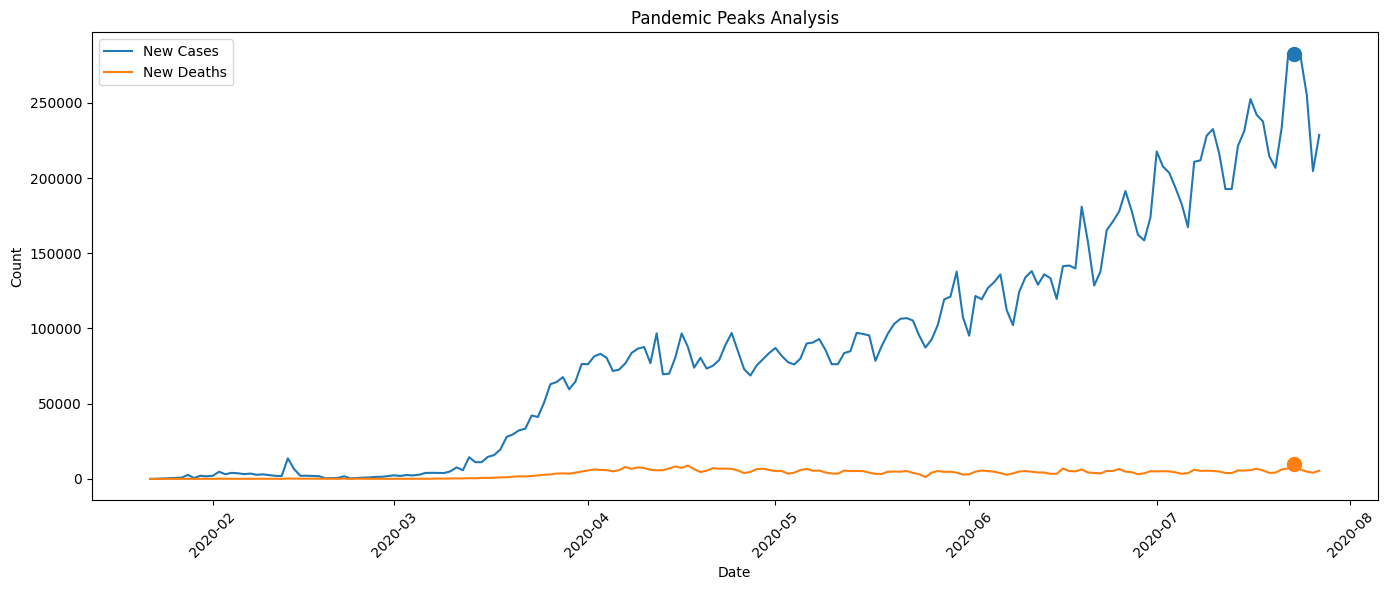

In [24]:
#19
max_cases_row = day_wise.orderBy(
    col("New cases").desc()
).first()

max_deaths_row = day_wise.orderBy(
    col("New deaths").desc()
).first()

print("Maximum New Cases:")
print(max_cases_row)

print("Maximum New Deaths:")
print(max_deaths_row)

day_wise_pd = day_wise.select(
    "Date",
    "New cases",
    "New deaths"
).orderBy("Date").toPandas()

plt.figure(figsize=(14, 6))

plt.plot(
    day_wise_pd["Date"],
    day_wise_pd["New cases"],
    label="New Cases"
)

plt.plot(
    day_wise_pd["Date"],
    day_wise_pd["New deaths"],
    label="New Deaths"
)

plt.scatter(
    max_cases_row["Date"],
    max_cases_row["New cases"],
    s=100
)

plt.scatter(
    max_deaths_row["Date"],
    max_deaths_row["New deaths"],
    s=100
)

plt.xlabel("Date")
plt.ylabel("Count")
plt.title("Pandemic Peaks Analysis")

plt.xticks(rotation=45)

plt.legend()

plt.tight_layout()
plt.show()

+-------------------+---------+-----------------+
|     Country/Region|Confirmed|Severity_Category|
+-------------------+---------+-----------------+
|        Afghanistan|    36263|           Medium|
|            Albania|     4880|              Low|
|            Algeria|    27973|           Medium|
|            Andorra|      907|              Low|
|             Angola|      950|              Low|
|Antigua and Barbuda|       86|              Low|
|          Argentina|   167416|             High|
|            Armenia|    37390|           Medium|
|          Australia|    15303|           Medium|
|            Austria|    20558|           Medium|
|         Azerbaijan|    30446|           Medium|
|            Bahamas|      382|              Low|
|            Bahrain|    39482|           Medium|
|         Bangladesh|   226225|             High|
|           Barbados|      110|              Low|
|            Belarus|    67251|           Medium|
|            Belgium|    66428|           Medium|


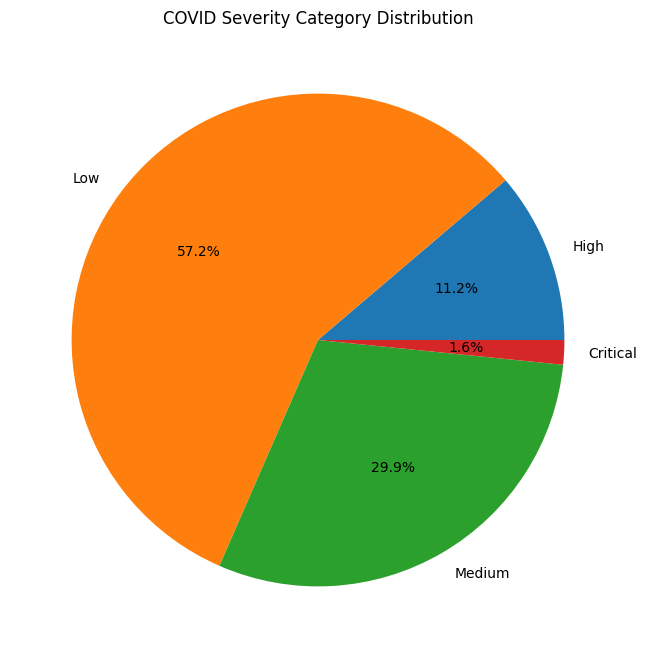

In [25]:
#20

country_wise = country_wise.withColumn(
    "Severity_Category",
    when(col("Confirmed") < 10000, "Low")
    .when((col("Confirmed") >= 10000) & (col("Confirmed") < 100000), "Medium")
    .when((col("Confirmed") >= 100000) & (col("Confirmed") < 1000000), "High")
    .otherwise("Critical")
)

country_wise.select(
    "Country/Region",
    "Confirmed",
    "Severity_Category"
).show()

severity_counts = country_wise.groupBy(
    "Severity_Category"
).agg(
    count("*").alias("Country_Count")
)

severity_counts.show()

severity_pd = severity_counts.toPandas()

plt.figure(figsize=(8, 8))

plt.pie(
    severity_pd["Country_Count"],
    labels=severity_pd["Severity_Category"],
    autopct="%1.1f%%"
)

plt.title("COVID Severity Category Distribution")

plt.show()